# Updating a Model from Plant Data

`28_data_reconciliation.ipynb` adjusted **measurements** to satisfy a model taken as
correct. This notebook asks the opposite question: what if the *model* is the thing
that has drifted?

Both are the same optimisation. A variable with a finite $\sigma$ is a measurement ---
you may move it, at a cost of $(x-y)^2/\sigma^2$. A variable with $\sigma = \infty$ is a
parameter --- move it freely, no cost. That single switch turns reconciliation into
estimation, so the interesting question is not *how* to update a model but **when you
are entitled to**.

The answer matters, because a free parameter can absorb a broken sensor and hand you a
confident, wrong number.

**What this notebook covers**

1. A pipe that fouls slowly while nobody is looking
2. Monitoring with the model held fixed --- the drift shows up in $\chi^2$
3. Telling a model fault from an instrument fault (the global test cannot; something else can)
4. Updating the parameter, and checking the update
5. Why you should *not* leave the parameter free all the time
6. Practical guidance

## 1. Setup

In [1]:
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

import numpy as np
import matplotlib.pyplot as plt
import difflow_gas as dg
from difflow_gas import verify
from difflow.reconciliation import (
    blame_concentration,
    global_test,
    measurement_test,
)

# palette: categorical slots 1-2, plus the reserved "critical" status step
BLUE, ORANGE, RED, GREY = "#2a78d6", "#eb6834", "#d03b3b", "#8a8985"
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#eceae6"

def tidy(ax, axis="y"):
    """Recessive axes and grid, so the data carries the emphasis."""
    ax.spines[["top", "right"]].set_visible(False)
    for s in ax.spines.values():
        s.set_color("#d5d4d0")
    ax.tick_params(colors=INK_SOFT, labelsize=8, length=3)
    ax.grid(axis=axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

RATIOS = {"cs1": 1.2}
P_SLACK_PA = 60.0e5


## 2. The plant and the model

Same five-node network as notebook 28. Pipe `p3` is the long leg of the `b-c-d` loop,
and it is the one that will foul: its effective resistance climbs above the design
value as deposits build up.

The *model* always believes `p3` is clean. The *plant* knows better.

In [2]:
def gas_network(eta_p3=1.0):
    """The network, with p3's resistance scaled by eta_p3 (>1 = fouled)."""
    return dg.GasNetwork(
        arcs={
            "p1":  ("src", "a", "pipe"),
            "cs1": ("a",   "b", "compressor"),
            "p2":  ("b",   "c", "pipe"),
            "p3":  ("b",   "d", "pipe"),
            "p4":  ("c",   "d", "pipe"),
        },
        beta={
            aid: dg.weymouth_beta(length_m=L, diameter_m=0.6, roughness_m=1e-4)
                 * (eta_p3 if aid == "p3" else 1.0)
            for aid, L in [("p1", 20e3), ("p2", 40e3), ("p3", 60e3), ("p4", 80e3)]
        },
        supply_kg_s={"src": 120.0, "c": -50.0, "d": -70.0},
    )

def plant_state(eta_p3):
    """The true pressures and flows of a plant whose p3 is fouled by eta_p3."""
    net = gas_network(eta_p3)
    fs, dec = dg.build_network_flowsheet(
        net, root="src", p_slack_pa=P_SLACK_PA, ratios=RATIOS
    )
    streams = fs.solve(tol=1e-12, max_iter=500)
    return (verify.node_pressures_bar(streams, dec),
            verify.arc_flows_kg_s(streams, dec))

model = gas_network(1.0)                     # what the engineers believe
layout = dg.gas_state_layout(model)
sigma = dg.measurement_sigma(layout)         # every variable metered

p0, q0 = plant_state(1.0)
print("clean-plant flows (kg/s):", {k: round(v, 2) for k, v in q0.items()})

clean-plant flows (kg/s): {'p1': 120.0, 'cs1': 120.0, 'p2': 64.61, 'p3': 55.39, 'p4': 14.61}


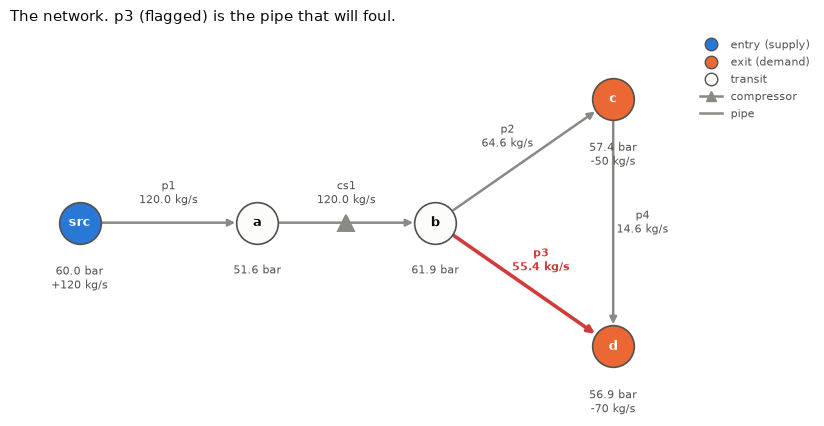

In [3]:
POS = {"src": (0, 0), "a": (1.15, 0), "b": (2.3, 0),
       "c": (3.45, 0.8), "d": (3.45, -0.8)}

fig, ax = plt.subplots(figsize=(8.5, 4.4))
dg.draw_network(
    model, ax=ax, pos=POS, pressures=p0, flows=q0, highlight=["p3"],
    title="The network. p3 (flagged) is the pipe that will foul.",
)
plt.tight_layout()
plt.show()

## 3. Sixty days of operation

Fouling begins on day 12 and grows steadily to 30% excess resistance. Nobody
measures it; the only evidence is that the meters stop agreeing with the model.

For contrast we also simulate a second plant where nothing fouls, but the `p2` flow
meter picks up a $6\sigma$ bias on day 30. Both faults will push $\chi^2$ up by a
similar amount --- which is exactly the difficulty.

In [4]:
DAYS = 45
FOUL_START = 12

eta_true = np.clip(
    1.0 + 0.30 * (np.arange(DAYS) - FOUL_START) / (DAYS - 1 - FOUL_START), 1.0, None
)

# solve the plant once per distinct fouling level, then reuse
levels = {e: plant_state(float(e)) for e in np.unique(np.round(eta_true, 4))}
x_true = {e: layout.pack(p, q, model.supply_kg_s) for e, (p, q) in levels.items()}
print(f"{len(levels)} distinct plant states solved")

33 distinct plant states solved


In [5]:
def simulate(scenario):
    """One day's measurements for each day of the campaign."""
    out = []
    for day in range(DAYS):
        if scenario == "fouling":
            xt = x_true[float(np.round(eta_true[day], 4))]
            gross = None
        else:                                    # clean pipe, bad p2 meter
            xt = x_true[1.0]
            gross = {"q_p2": 6.0} if day >= 30 else None
        out.append(dg.perturb(xt, sigma, jax.random.PRNGKey(1000 + day),
                              layout=layout, gross_errors=gross))
    return out

data_foul = simulate("fouling")
data_sens = simulate("sensor")

# monitor_network reconciles each day against the SAME fixed model and keeps
# the diagnostics. Holding the model and the sigmas still is what makes the
# series readable: every wobble in it comes from the data.
mon_foul = dg.monitor_network(model, data_foul, sigma, layout, ratios=RATIOS)
mon_sens = dg.monitor_network(model, data_sens, sigma, layout, ratios=RATIOS)

chi_foul, chi_sens = mon_foul.statistic, mon_sens.statistic
CRIT = mon_foul.critical

print(f"reject above chi2 = {CRIT:.2f} on {mon_foul.dof} dof")
print(f"last 10 days -- fouling: {chi_foul[-10:].mean():.1f}, "
      f"sensor fault: {chi_sens[-10:].mean():.1f}")


reject above chi2 = 18.31 on 10 dof
last 10 days -- fouling: 37.8, sensor fault: 42.3


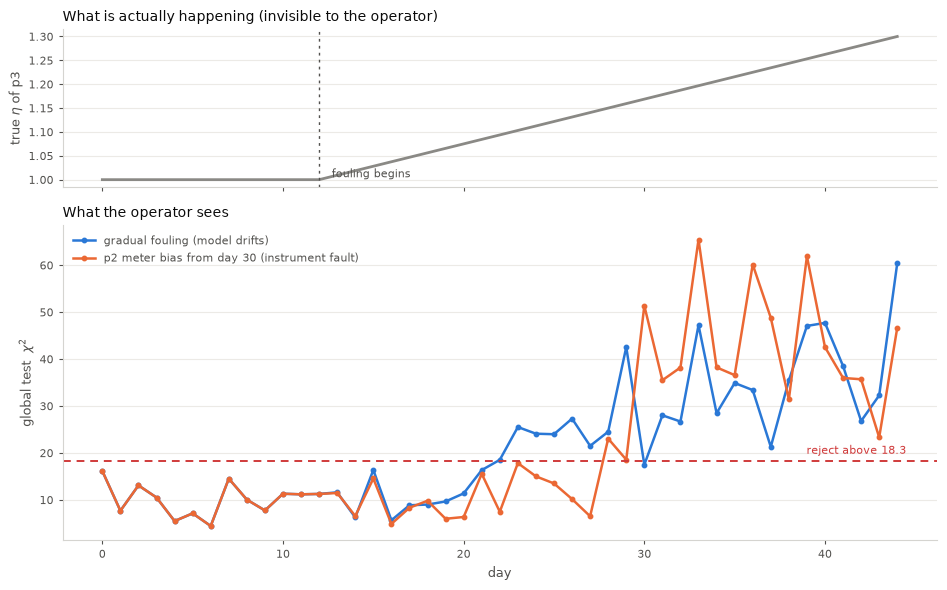

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9.5, 6.0), sharex=True,
                         gridspec_kw={"height_ratios": [1, 2]})

ax = axes[0]
ax.plot(eta_true, color=GREY, linewidth=2)
ax.set_ylabel("true $\\eta$ of p3", fontsize=9, color=INK_SOFT)
ax.set_title("What is actually happening (invisible to the operator)",
             fontsize=10, color=INK, loc="left")
ax.axvline(FOUL_START, color=INK_SOFT, linestyle=(0, (2, 3)), linewidth=1)
ax.text(FOUL_START + 0.7, 1.005, "fouling begins", fontsize=8, color=INK_SOFT)
tidy(ax)

ax = axes[1]
ax.plot(chi_foul, color=BLUE, linewidth=1.8, marker="o", markersize=3.2,
        label="gradual fouling (model drifts)")
ax.plot(chi_sens, color=ORANGE, linewidth=1.8, marker="o", markersize=3.2,
        label="p2 meter bias from day 30 (instrument fault)")
ax.axhline(CRIT, color=RED, linestyle=(0, (4, 3)), linewidth=1.4)
ax.text(DAYS - 0.5, CRIT + 1.5, f"reject above {CRIT:.1f}", fontsize=8,
        color=RED, ha="right")
ax.set_xlabel("day", fontsize=9, color=INK_SOFT)
ax.set_ylabel("global test  $\\chi^2$", fontsize=9, color=INK_SOFT)
ax.set_title("What the operator sees", fontsize=10, color=INK, loc="left")
ax.legend(frameon=False, fontsize=8, loc="upper left", labelcolor=INK_SOFT)
tidy(ax)

plt.tight_layout()
plt.show()

Both faults raise $\chi^2$ through the threshold, and by the end of the campaign they
raise it by a *similar* amount. The global test says "your data and your model
disagree." It cannot say which of the two is at fault --- it never could, because it
only measures the size of the disagreement.

## 4. Telling a model fault from an instrument fault

The measurement test can, but not from any single day. Look at **which** sensor it
blames, day after day.

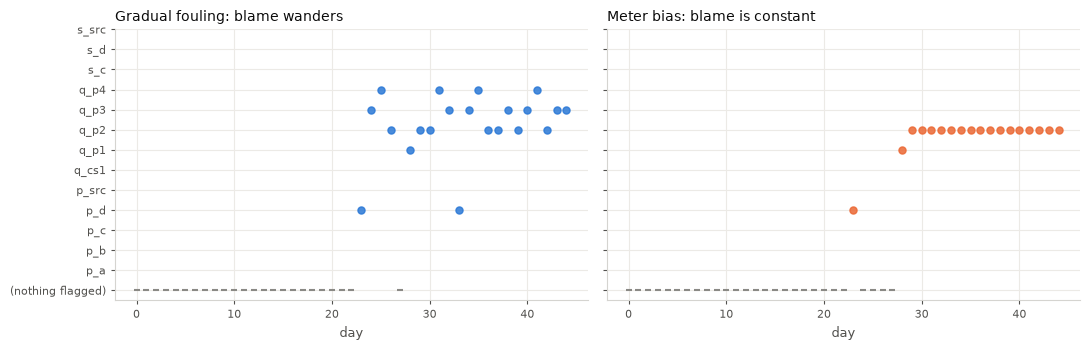

gradual fouling    40% on q_p3
meter bias        100% on q_p2

fouling : model drift: 93% of the last 15 steps reject, blame concentration 40%
sensor  : instrument fault: 100% of the last 15 steps reject, blame concentration 100%, on q_p2


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
order = layout.names

for ax, susp, title, colour in [
    (axes[0], mon_foul.suspects, "Gradual fouling: blame wanders", BLUE),
    (axes[1], mon_sens.suspects, "Meter bias: blame is constant", ORANGE),
]:
    days = [d for d, s in enumerate(susp) if s is not None]
    rows = [order.index(susp[d]) for d in days]
    ax.scatter(days, rows, s=26, color=colour, alpha=0.85)
    none_days = [d for d, s in enumerate(susp) if s is None]
    ax.scatter(none_days, [-1] * len(none_days), s=20, color=GREY, marker="_")
    ax.set_yticks(range(-1, len(order)))
    ax.set_yticklabels(["(nothing flagged)"] + order, fontsize=7.5)
    ax.set_xlabel("day", fontsize=9, color=INK_SOFT)
    ax.set_title(title, fontsize=10, color=INK, loc="left")
    tidy(ax, axis="both")

plt.tight_layout()
plt.show()

# blame_concentration: what fraction of the window blames one single sensor,
# counting the quiet days too -- a campaign that rarely rejects should not
# read as a concentrated fault just because its few rejections agreed.
for tag, mon in [("gradual fouling", mon_foul), ("meter bias", mon_sens)]:
    fraction, culprit = blame_concentration(mon.suspects, window=15)
    print(f"{tag:<16} {fraction:>5.0%} on {culprit}")

print()
print("fouling :", mon_foul.diagnose(window=15))
print("sensor  :", mon_sens.diagnose(window=15))


That is the diagnostic. A broken instrument is blamed by name, every day, because the
bias sits on one variable and the redundancy points straight at it. A drifting model
produces a mismatch the adjustments spread around, so the prime suspect keeps changing
and on some days nothing crosses the threshold at all.

`diagnose()` reads the two together and returns the verdict: persistent rejection with
a *concentrated* suspect is an instrument problem --- go and calibrate it; persistent
rejection with a *diffuse* suspect is a model problem, and only then are you entitled
to update a parameter. Both thresholds are arguments, so the rule can be tuned to a
plant's own noise; the defaults are half the window rejecting and 60% of it agreeing
on one sensor.

## 5. Updating the parameter

Now, and only now, let $\eta$ float. One day's data would give a noisy estimate, so
pool a window of days --- `reconcile_network_multi` does that in a single solve, with
$\eta$ appearing once and every day's equations constraining it.


In [8]:
layout_eta = dg.gas_state_layout(model, efficiency_arcs=["p3"])
sigma_eta = dg.measurement_sigma(layout_eta)      # eta defaults to unmeasured

WINDOW = 10
# embed() re-packs each day's measurements into the layout that carries eta,
# by name -- the added entry is unmeasured, so it is filled with nan.
window = [layout_eta.embed(y, layout) for y in data_foul[-WINDOW:]]

pooled = dg.reconcile_network_multi(
    model, window, sigma_eta, layout_eta, shared=["eta_p3"], ratios=RATIOS
)
eta_hat = pooled.shared["eta_p3"]
eta_sd = pooled.shared_std["eta_p3"]

# for comparison, the same window one day at a time
singles = [
    dg.reconcile_network(model, y, sigma_eta, layout_eta, ratios=RATIOS)
    for y in window
]
per_day = np.array([r.x_named["eta_p3"] for r in singles])
per_day_sd = float(np.mean([r.std["eta_p3"] for r in singles]))

print(f"pooled over the last {WINDOW} days : {eta_hat:.4f} +- {eta_sd:.4f}")
print(f"  averaging the daily estimates  : {per_day.mean():.4f} "
      f"+- {per_day_sd:.4f}  (one day's error bar)")
print(f"  spread across those days       : {per_day.std():.4f}")
print(f"  sqrt({WINDOW}) tighter would be     : "
      f"{per_day_sd / np.sqrt(WINDOW):.4f}")
print()
print(f"  true mean over the same window : {eta_true[-WINDOW:].mean():.4f}")
print(f"  true value on the final day    : {eta_true[-1]:.4f}")
print()
print(f"degrees of redundancy: {pooled.structure.degree_of_redundancy} "
      f"(vs {singles[0].structure.degree_of_redundancy} x {WINDOW} = "
      f"{singles[0].structure.degree_of_redundancy * WINDOW} "
      f"reconciling separately)")


pooled over the last 10 days : 1.2636 +- 0.0174
  averaging the daily estimates  : 1.2654 +- 0.0551  (one day's error bar)
  spread across those days       : 0.0610
  sqrt(10) tighter would be     : 0.0174

  true mean over the same window : 1.2578
  true value on the final day    : 1.3000

degrees of redundancy: 99 (vs 9 x 10 = 90 reconciling separately)


Three things to read here.

The pooled standard error is $\sqrt{K}$ tighter than a single day's, and that is not a
bookkeeping trick: $\eta$ appears *once* in the stacked problem, so each day spends its
equations constraining the same unknown instead of ten private copies of it. The
degrees of redundancy count it --- pooling recovers the nine that ten separate
estimations throw away. Averaging the daily point estimates lands in the same place but
leaves you holding one day's error bar for a quantity ten of them informed.

The day-to-day spread and the single-day standard error agree, which is the check that
the uncertainty is honest --- a spread much larger than the reported $\sigma$ would mean
the model is missing a source of variation.

And the estimate tracks the window's *average* truth, not the final day's. That lag is
unavoidable while the parameter is still moving: any estimate of a drifting quantity is
a statement about the recent past, and pooling widens the past it averages over. Choose
a window short enough that $\eta$ is roughly constant across it.

Update the model and re-run the last stretch of the campaign against it.


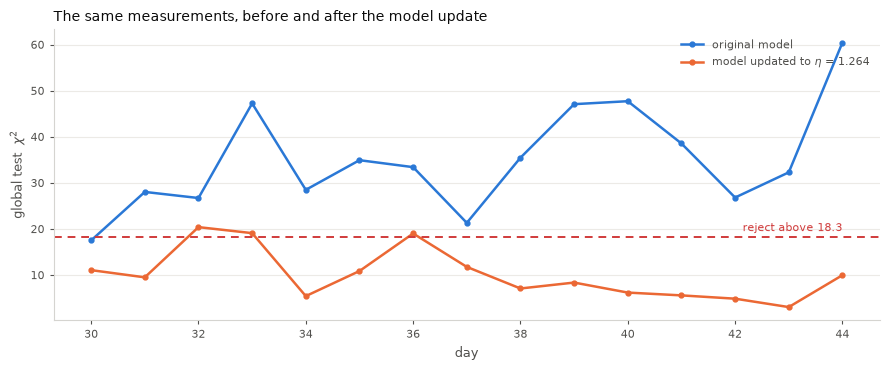

mean chi2  before  35.04   after  10.12   (expected ~10 on 10 dof if the model is right)


In [9]:
updated = gas_network(eta_hat)          # the model, corrected

TAIL = 15
chi_before = mon_foul.statistic[-TAIL:]
chi_after = dg.monitor_network(
    updated, data_foul[-TAIL:], sigma, layout, ratios=RATIOS
).statistic

days = np.arange(DAYS - TAIL, DAYS)
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(days, chi_before, color=BLUE, linewidth=1.8, marker="o", markersize=3.5,
        label="original model")
ax.plot(days, chi_after, color=ORANGE, linewidth=1.8, marker="o", markersize=3.5,
        label=f"model updated to $\\eta$ = {eta_hat:.3f}")
ax.axhline(CRIT, color=RED, linestyle=(0, (4, 3)), linewidth=1.4)
ax.text(days[-1], CRIT + 1.2, f"reject above {CRIT:.1f}", fontsize=8, color=RED,
        ha="right")
ax.set_xlabel("day", fontsize=9, color=INK_SOFT)
ax.set_ylabel("global test  $\\chi^2$", fontsize=9, color=INK_SOFT)
ax.set_title("The same measurements, before and after the model update",
             fontsize=10, color=INK, loc="left")
ax.legend(frameon=False, fontsize=8, loc="upper right", labelcolor=INK_SOFT)
tidy(ax)
plt.tight_layout()
plt.show()

print(f"mean chi2  before {chi_before.mean():6.2f}   after {chi_after.mean():6.2f}"
      f"   (expected ~{mon_foul.dof} on {mon_foul.dof} dof if the model is right)")

The same data that rejected the old model is unremarkable against the updated one.
Nothing about the measurements changed --- only what we now believe about the pipe.

A couple of days still brush the threshold, and that is the lag above showing up: by the
final day the pipe is dirtier than the window average the estimate was built from. It is
the signal that the next update is already due.

One caveat worth being explicit about: the updated model describes the plant **as it is
now**. Re-run it against day 15's data and it will reject, correctly, because the pipe
really was cleaner then. A parameter update is a statement about the present, not a
retroactive correction, and fouling that keeps progressing will need updating again.

## 6. Why not just leave the parameter free?

If a free $\eta$ fixes a drifting model, why fix it at all? Because a free parameter
absorbs whatever is wrong --- including a lying sensor.

Feed the **instrument-fault** data to a reconciliation with $\eta$ free, and watch it
manufacture a fouling estimate out of a bad meter.

In [10]:
y_bad = data_sens[-1]                          # p2 meter biased, pipe is clean
y_bad_eta = layout_eta.embed(y_bad, layout)

fixed = dg.reconcile_network(model, y_bad, sigma, layout, ratios=RATIOS)
free = dg.reconcile_network(model, y_bad_eta, sigma_eta, layout_eta, ratios=RATIOS)

print(f"{'':22} {'chi2':>8} {'verdict':>10} {'suspect':>9} {'eta estimate':>14}")
print("-" * 68)
for tag, res, eta in [("parameter fixed", fixed, None),
                      ("parameter free", free, free.x_named["eta_p3"])]:
    g, m = global_test(res), measurement_test(res)
    print(f"{tag:22} {g.statistic:8.2f} {'REJECT' if g.detected else 'accept':>10} "
          f"{str(m.suspect):>9} {('fixed at 1.000' if eta is None else f'{eta:.3f}'):>14}")

print(f"\nthe pipe is genuinely clean (eta = 1.000)")

                           chi2    verdict   suspect   eta estimate
--------------------------------------------------------------------
parameter fixed           46.67     REJECT      q_p2 fixed at 1.000
parameter free            25.25     REJECT      q_p2          1.221

the pipe is genuinely clean (eta = 1.000)


With $\eta$ free the statistic falls, because the parameter has soaked up part of the
bias --- and the fouling estimate it reports is not 1.0. A single meter fault has been
converted into a confident statement about a pipe nobody inspected.

That is the whole argument for the two-clock discipline below. In the routine loop the
model has no freedom, so the $\chi^2$ test is a genuine instrument-health monitor. Give
the model freedom and you trade that monitor away for a number that always looks fine.

## 7. Closing the loop

Sections 5 and 6 describe a discipline a *person* applies: watch the monitor, read
the verdict, decide you are entitled to re-estimate, pool a window, rebuild the
model. A digital twin --- a model kept current so that what you optimise and price
against is the plant as it *is* --- has nobody to apply it. Automating it naively
breaks it in two places.

**The verdict has to gate the update, not advise it.** Section 6 is what happens
otherwise: the free parameter absorbs the meter bias, reports fouling on a clean
pipe, and $\chi^2$ *falls* while it does. Nothing about a slower update prevents
that --- it would just arrive at the same wrong number more gradually.

**The update needs a memory.** The pooled estimate of section 5 is a *rectangular*
filter: hard edges, a ten-day-old day weighted like today, rebuilt from scratch each
time. Re-run it on a schedule and the estimate lurches as days fall off the back.

`track_parameters` is those two fixes. Each day it reconciles with $\eta$ **frozen**
at the current estimate (clock one, so the tests still mean something), reads the
verdict, and only where the verdict is `model drift` does it estimate $\eta$ from
that day and fold the result into a random walk (clock two).

In [11]:
from difflow.reconciliation import (
    TrackerState, drift_std_from_time_constant, track_parameters,
)

# One residual function serves both clocks. eta_p3 arrives through `params`
# rather than baked into the network, because GasNetwork validates its
# arguments with Python comparisons and so cannot be built under a trace.
def gas_residuals(x, params):
    return dg.residuals.network_residuals(
        x, model, layout, ratios=RATIOS,
        efficiencies={"p3": params["eta_p3"]},
    )

# "the pipe might foul by 10% in a month" -- the question an engineer can
# actually answer -- converted into the random-walk rate the filter wants.
DRIFT = drift_std_from_time_constant(0.10, 30.0)

# The diagnose() rule, tuned to this network. At the defaults (window 15,
# 60% concentration) a couple of days of the meter-bias campaign read as
# diffuse and slip through the gate; a longer window fixes it. Tuning the
# rule is the right response to that -- widening `allow` is not.
GATE = dict(window=21, concentration_threshold=0.4)

def track(data, **kw):
    run = track_parameters(
        gas_residuals, data, sigma,
        state=TrackerState.initial(["eta_p3"], [1.0], std=[0.02]),
        drift_std=DRIFT, names=layout.names,
        unmeasured_scale=layout.default_scale, **GATE, **kw,
    )
    jax.clear_caches()        # each day traces a fresh closure
    return run

tracked = track(data_foul)

first = next(s.index for s in tracked.steps if s.updated)
print(f"drift_std        {float(DRIFT):.4f} per day")
print(f"first update     day {first}   (fouling began on day {FOUL_START})")
print(f"final estimate   {tracked.of('eta_p3')[-1]:.3f} "
      f"+- {tracked.std_of('eta_p3')[-1]:.3f}   (true {eta_true[-1]:.3f})")
print(f"updates          {tracked.n_updates} of {len(tracked)} days")

drift_std        0.0183 per day
first update     day 33   (fouling began on day 12)
final estimate   1.257 +- 0.039   (true 1.300)
updates          10 of 45 days


The loop spends most of the campaign doing nothing, which is the design. While the
verdict is `consistent` the gate stays shut and $\eta$ does not move --- but the
*time update* still runs, so its error bar widens day by day at the drift rate. A
held parameter is not a known parameter, and the twin says so.

Then the evidence accumulates, the verdict flips, and the gate opens.

For contrast, run the same filter with the gate wired open --- re-estimating every
day regardless of the verdict.

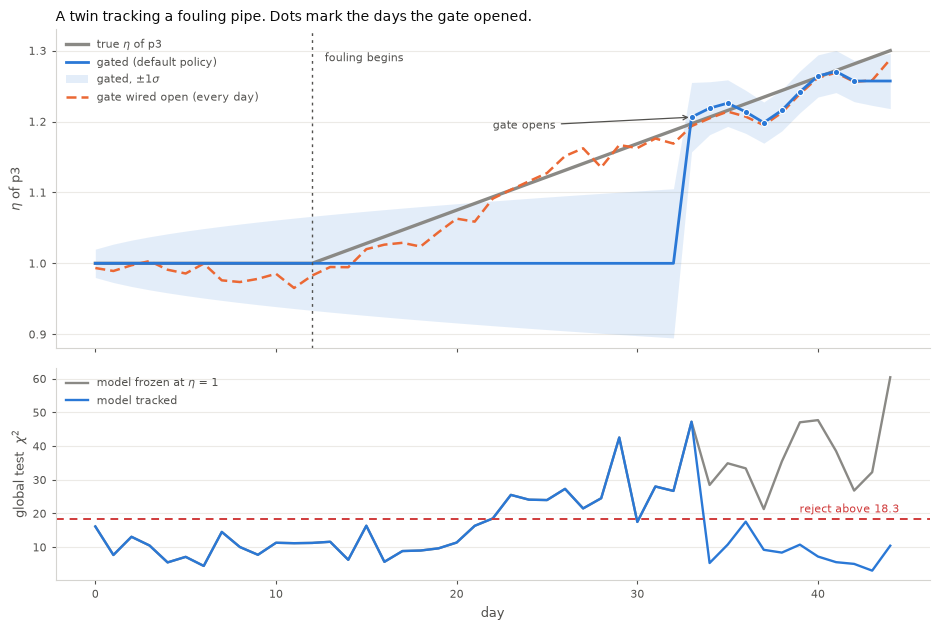

                            final eta   mean |err| last 10 d   updates
----------------------------------------------------------------------
gated (default policy)          1.257                 0.0200        10
gate wired open                 1.288                 0.0178        45


In [12]:
from difflow.reconciliation import (
    MONITOR_CONSISTENT, MONITOR_INSTRUMENT_FAULT, MONITOR_MODEL_DRIFT,
    MONITOR_UNDIAGNOSED,
)

EVERY_DAY = [MONITOR_CONSISTENT, MONITOR_INSTRUMENT_FAULT,
             MONITOR_MODEL_DRIFT, MONITOR_UNDIAGNOSED]
ungated = track(data_foul, allow=EVERY_DAY)

days = np.arange(DAYS)
eta_g, eta_u = tracked.of("eta_p3"), ungated.of("eta_p3")
sd_g = tracked.std_of("eta_p3")
marks = [s.index for s in tracked.steps if s.updated]

fig, axes = plt.subplots(2, 1, figsize=(9.5, 6.4), sharex=True,
                         gridspec_kw={"height_ratios": [3, 2]})

ax = axes[0]
ax.plot(days, eta_true, color=GREY, linewidth=2.4, label="true $\\eta$ of p3")
ax.fill_between(days, eta_g - sd_g, eta_g + sd_g, color=BLUE, alpha=0.13,
                linewidth=0, label="gated, $\\pm 1\\sigma$")
ax.plot(days, eta_u, color=ORANGE, linewidth=1.8, linestyle=(0, (4, 2)),
        label="gate wired open (every day)")
ax.plot(days, eta_g, color=BLUE, linewidth=2.0, label="gated (default policy)")
ax.plot(marks, eta_g[marks], linestyle="none", marker="o", markersize=4.5,
        color=BLUE, markeredgecolor="white", markeredgewidth=0.8)
ax.axvline(FOUL_START, color=INK_SOFT, linestyle=(0, (2, 3)), linewidth=1)
ax.text(FOUL_START + 0.7, 1.285, "fouling begins", fontsize=8, color=INK_SOFT)
ax.annotate("gate opens", xy=(first, eta_g[first]), xytext=(first - 11, 1.19),
            fontsize=8, color=INK_SOFT,
            arrowprops=dict(arrowstyle="->", color=INK_SOFT, linewidth=0.9))
ax.set_ylim(0.88, 1.33)          # the held band is wide on purpose
ax.set_ylabel("$\\eta$ of p3", fontsize=9, color=INK_SOFT)
ax.set_title("A twin tracking a fouling pipe. Dots mark the days the gate opened.",
             fontsize=10, color=INK, loc="left")
h, l = ax.get_legend_handles_labels()
order = [l.index(k) for k in ["true $\\eta$ of p3", "gated (default policy)",
                              "gated, $\\pm 1\\sigma$",
                              "gate wired open (every day)"]]
ax.legend([h[k] for k in order], [l[k] for k in order], frameon=False,
          fontsize=8, loc="upper left", labelcolor=INK_SOFT)
tidy(ax)

ax = axes[1]
ax.plot(days, mon_foul.statistic, color=GREY, linewidth=1.7,
        label="model frozen at $\\eta$ = 1")
ax.plot(days, tracked.monitor.statistic, color=BLUE, linewidth=1.7,
        label="model tracked")
ax.axhline(CRIT, color=RED, linestyle=(0, (4, 3)), linewidth=1.4)
ax.text(DAYS - 0.5, CRIT + 2.0, f"reject above {CRIT:.1f}", fontsize=8,
        color=RED, ha="right")
ax.set_xlabel("day", fontsize=9, color=INK_SOFT)
ax.set_ylabel("global test  $\\chi^2$", fontsize=9, color=INK_SOFT)
ax.legend(frameon=False, fontsize=8, loc="upper left", labelcolor=INK_SOFT)
tidy(ax)

plt.tight_layout()
plt.show()

tail = slice(-10, None)
print(f"{'':26} {'final eta':>10} {'mean |err| last 10 d':>22} {'updates':>9}")
print("-" * 70)
for tag, e, r in [("gated (default policy)", eta_g, tracked),
                  ("gate wired open", eta_u, ungated)]:
    print(f"{tag:26} {e[-1]:10.3f} "
          f"{np.abs(e[tail] - eta_true[tail]).mean():22.4f} {r.n_updates:9d}")

Two things to read.

**The loop closes.** The lower panel is the same data scored against a model that
moves. Frozen at $\eta = 1$ it rejects for the whole back half of the campaign;
tracked, it drops back under the threshold after each update and stays there. That
is the test doing its job again --- and a $\chi^2$ that *failed* to come back down
would be the signal that no value of $\eta$ fits and the mismatch is structural.

**The gate costs accuracy, and that is the trade.** Opening it every day tracks the
drift slightly better, because it never waits for evidence. The gated loop lags:
fouling starts on day 12 and the gate does not open until the rejection is
persistent, so for three weeks the twin holds a model it already has some reason to
doubt --- and says so through a widening error bar rather than by guessing.

Whether that lag is worth paying is decided by the other campaign.

In [13]:
sens_gated = track(data_sens)
sens_open = track(data_sens, allow=EVERY_DAY)

print("the p2 meter is biased from day 30; the pipe is genuinely clean "
      "(eta = 1.000)\n")
print(f"{'':26} {'fouling campaign':>18} {'meter-bias campaign':>21}")
print("-" * 70)
for tag, a, b in [("gated (default policy)", tracked, sens_gated),
                  ("gate wired open", ungated, sens_open)]:
    print(f"{tag:26} {a.of('eta_p3')[-1]:18.3f} "
          f"{b.of('eta_p3')[-1]:21.3f}")
print(f"{'true value':26} {eta_true[-1]:18.3f} {1.0:21.3f}")
print()

from collections import Counter
print("verdicts on the meter-bias campaign:",
      dict(Counter(s.diagnosis.verdict for s in sens_gated.steps)))
print(f"updates: {sens_gated.n_updates} gated, {sens_open.n_updates} wired open")

the p2 meter is biased from day 30; the pipe is genuinely clean (eta = 1.000)

                             fouling campaign   meter-bias campaign
----------------------------------------------------------------------
gated (default policy)                  1.257                 1.000
gate wired open                         1.288                 1.165
true value                              1.300                 1.000

verdicts on the meter-bias campaign: {'consistent': 38, 'instrument fault': 7}
updates: 0 gated, 45 wired open


There is the answer. Read the columns together:

|  | fouling campaign | meter-bias campaign |
|---|---|---|
| **gated** | 1.257 (true 1.300) --- lags | **1.000 --- correct, never moved** |
| **wired open** | 1.288 (true 1.300) --- tracks | **1.165 --- fouling invented** |

Opening the gate buys about 0.03 in $\eta$ on the campaign where the model really
was wrong, and costs a confident 16% fouling claim on a pipe that was clean. The
gated loop never updates on the meter-bias campaign at all: every day is either
`consistent` or `instrument fault`, and neither entitles the model to move. What it
reports instead is a widening error bar on $\eta$ and a named suspect to go and
calibrate --- which is the correct output, because the pipe is fine and the meter
is not.

One caveat, and it is why `window` and `concentration_threshold` are arguments
above rather than fixed. The gate is a **statistical rule, not a guarantee**. At the
defaults on this small network a couple of days early in the bias read as diffuse,
slip through as `model drift`, and drag $\eta$ to 1.13 before the rule settles. The
fix is to tune the rule to the plant's own noise --- lengthen the window, lower the
concentration threshold --- and `track_parameters` forwards both to `diagnose`. The
fix is *not* to widen `allow`, which removes the rule rather than sharpening it.

**What this still does not fix.** The filter corrects a parameter, not the model's
*form*. If the network were wrong in shape --- a missing leg, the wrong pipe law ---
no value of $\eta$ would fit, $\chi^2$ would stay above the line after every update,
and the twin's *gradients* would be wrong even on days its values happened to
match. That is fatal for a differentiable flowsheet, where everything downstream is
a derivative. `difflow.planning.modifiers` corrects values and gradients together
and is the right tool there; a faster filter is not.

## Summary

| | Data reconciliation | Parameter estimation |
|---|---|---|
| What moves | the measurements | the model coefficients |
| In code | finite `sigma` | `sigma = inf` |
| Assumes | model right, sensors wrong | sensors right, model wrong |
| Costs | nothing | one degree of redundancy each |

They are one optimisation, separated only by which weights you set to zero. What
separates them in *practice* is the discipline about when each is allowed to run.

**Two clocks**

- **Routine (hourly, daily): parameters fixed.** `monitor_network` runs this one. The
  $\chi^2$ test is then a real instrument-health monitor, because the model cannot flex
  to hide a fault, and `diagnose()` reads the series for you.
- **Campaign (weekly, monthly): re-estimate parameters.** `reconcile_network_multi`
  pools the window. Trigger it on *persistent rejection with a diffuse suspect* --- the
  signature of a model fault, section 4 --- never on a single bad day, and never on a
  concentrated suspect, which means go calibrate a meter instead.

**Both clocks, run for you.** `track_parameters` (section 7) is the pair written as an
update law, for a twin where nobody is there to apply the discipline by hand. The
verdict *gates* the re-estimation instead of advising it, and what gets through is
filtered onto a random walk whose rate you choose --- so the parameter moves at a pace
you set rather than at the pace one day's noise suggests. The cost is a detection lag;
the thing it buys is that a biased meter never becomes a statement about a pipe.

**Reading the two tests together**

| $\chi^2$ | suspect | reading |
|---|---|---|
| accept | — | healthy |
| reject once | any | noise, or a transient; wait |
| reject persistently | same name every day | instrument fault --- calibrate it |
| reject persistently | wanders, often none | model drift --- estimate the parameter |

**What the differentiability bought here:** the parameter update is not a separate
fitting code path. It is the same `reconcile` call with one `sigma` set to infinity,
and the standard error on $\eta$ comes from the same covariance matrix as every
reconciled flow. Pooling a window does not change that either --- it stacks the same
KKT system over ten days with $\eta$ shared, which is why its error bar shrinks by
$\sqrt{10}$ and its degrees of redundancy go up rather than down.